#  Image Classification with CNNs




In [4]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


## Install and Import Libraries

In [5]:
import os, random, warnings, time, zipfile, shutil
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
import seaborn as sns
warnings.filterwarnings('ignore')

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, models
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.preprocessing import image as kimg
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

from sklearn.metrics import classification_report, confusion_matrix
from pathlib import Path

print(f"TensorFlow: {tf.__version__}")
print(f"GPU: {tf.config.list_physical_devices('GPU')}")

TensorFlow: 2.20.0
GPU: []


## 1. Dataset Setup


In [6]:
import os, zipfile

EXTRACT_TO = "/content/drive/MyDrive/AI   ML Final Assignment/Insect Classification"

# Find data root (adjust path if your zip structure is different)
DATA_ROOT = "/content/drive/MyDrive/AI   ML Final Assignment/Insect Classification"
print("Contents:", os.listdir(DATA_ROOT) if os.path.exists(DATA_ROOT) else "NOT FOUND")

Contents: ['test', 'train']


###  Create Train / Val / Test Split



In [7]:
SOURCE_DIR = Path(DATA_ROOT) / "test"
OUTPUT_DIR = Path("/content/dataset")
CLASSES = ['aphids', 'armyworm', 'mosquito', 'sawfly', 'stem_borer']
TRAIN_RATIO, VAL_RATIO = 0.70, 0.15

random.seed(42)
for split in ['train', 'val', 'test']:
    for cls in CLASSES:
        (OUTPUT_DIR / split / cls).mkdir(parents=True, exist_ok=True)

for cls in CLASSES:
    images = list((SOURCE_DIR / cls).glob("*.jpg"))
    random.shuffle(images)
    n = len(images)
    n_train = int(n * TRAIN_RATIO)
    n_val = int(n * VAL_RATIO)
    splits = {'train': images[:n_train],
              'val': images[n_train:n_train+n_val],
              'test': images[n_train+n_val:]}
    for split, files in splits.items():
        for f in files:
            shutil.copy(f, OUTPUT_DIR / split / cls / f.name)
    print(f"{cls}: {n_train} train | {n_val} val | {n-n_train-n_val} test")

TRAIN_DIR = str(OUTPUT_DIR / "train")
VAL_DIR = str(OUTPUT_DIR / "val")
TEST_DIR = str(OUTPUT_DIR / "test")
IMG_SIZE = 128
BATCH_SIZE = 8
NUM_CLASSES = 5
print("Split complete.")

aphids: 30 train | 6 val | 8 test
armyworm: 30 train | 6 val | 7 test
mosquito: 35 train | 7 val | 8 test
sawfly: 25 train | 5 val | 7 test
stem_borer: 25 train | 5 val | 6 test
Split complete.


## 2. Data Analysis and Visualization

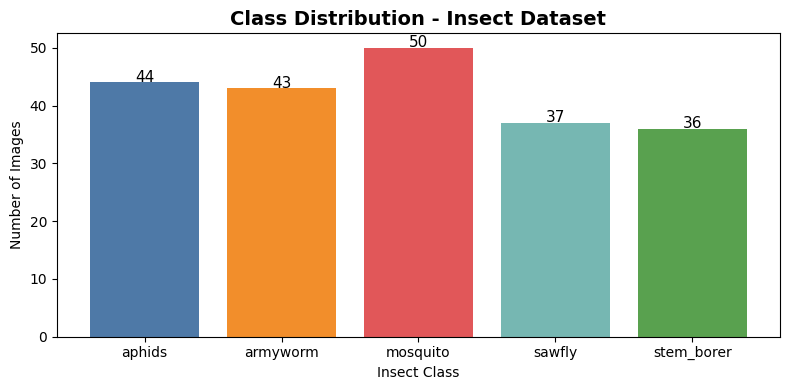

Observation: Dataset has 5 classes with roughly balanced distribution (6-10 images each).
This is a VERY small dataset - data augmentation is essential.


In [8]:
# Class distribution bar chart
counts = {}
for cls in CLASSES:
    counts[cls] = len(list((SOURCE_DIR / cls).glob("*.jpg")))

fig, ax = plt.subplots(figsize=(8, 4))
colors = ['#4e79a7','#f28e2b','#e15759','#76b7b2','#59a14f']
bars = ax.bar(counts.keys(), counts.values(), color=colors)
ax.set_title("Class Distribution - Insect Dataset", fontsize=14, fontweight='bold')
ax.set_xlabel("Insect Class")
ax.set_ylabel("Number of Images")
for bar, v in zip(bars, counts.values()):
    ax.text(bar.get_x() + bar.get_width()/2, v + 0.1, str(v), ha='center', fontsize=11)
plt.tight_layout()
plt.savefig("class_distribution.png", dpi=150)
plt.show()
print("Observation: Dataset has 5 classes with roughly balanced distribution (6-10 images each).")
print("This is a VERY small dataset - data augmentation is essential.")

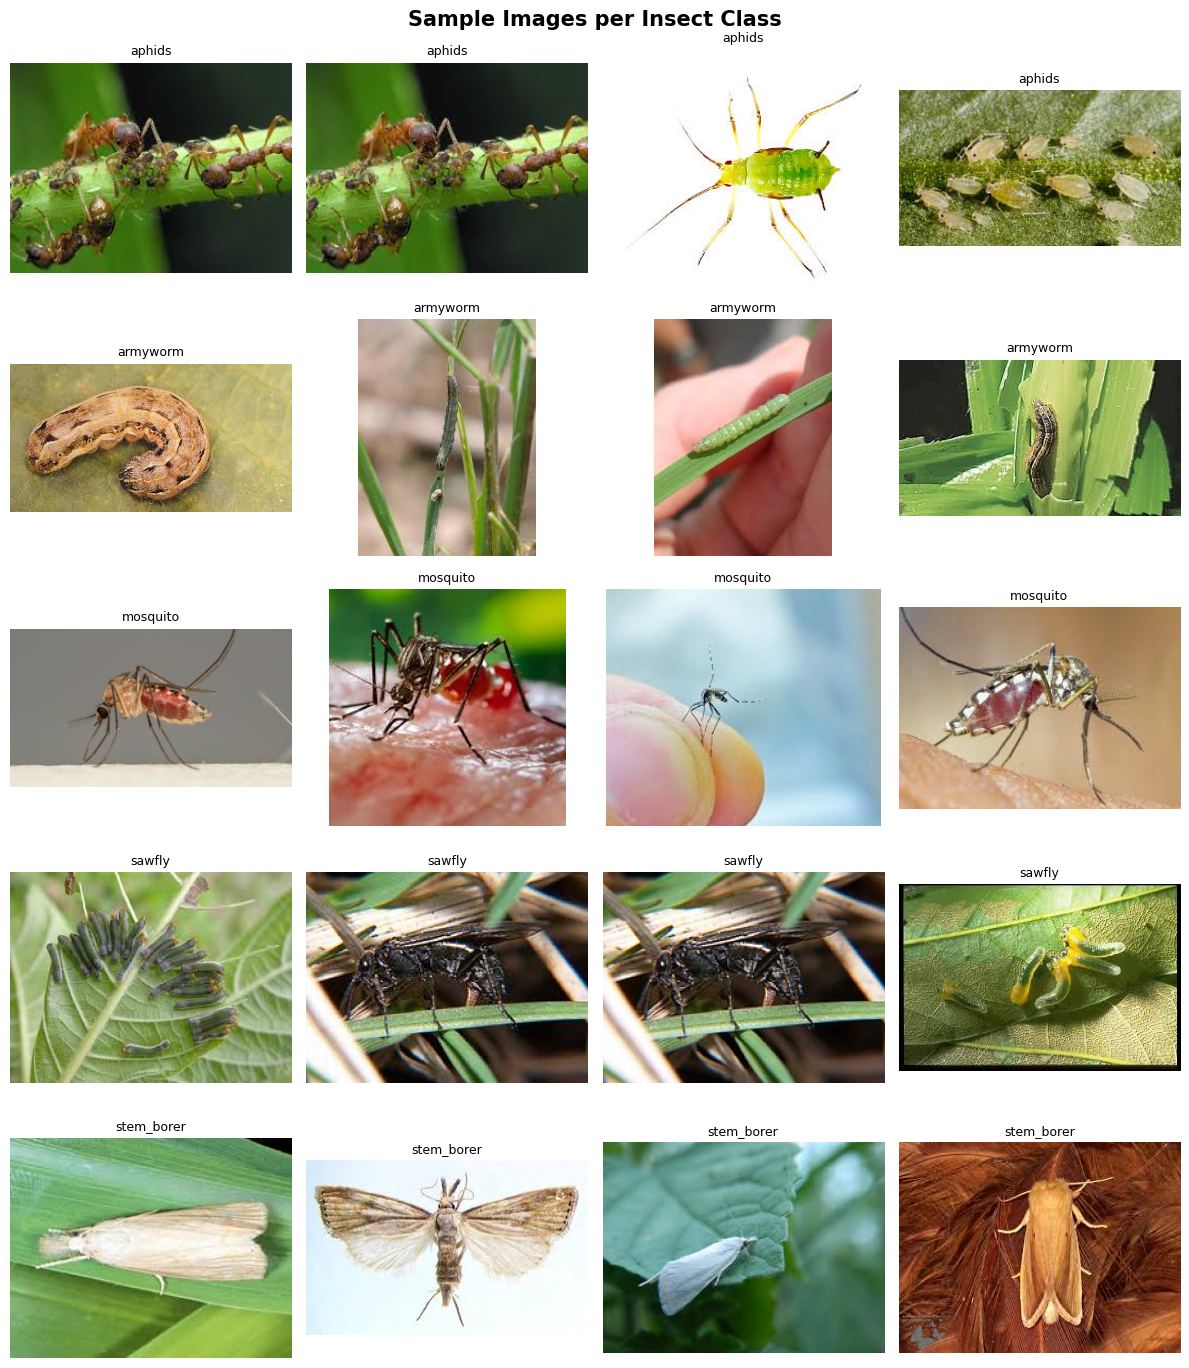

In [9]:
# Sample images per class
fig, axes = plt.subplots(5, 4, figsize=(12, 14))
fig.suptitle("Sample Images per Insect Class", fontsize=15, fontweight='bold')
for row, cls in enumerate(CLASSES):
    img_paths = list((SOURCE_DIR / cls).glob("*.jpg"))[:4]
    for col, path in enumerate(img_paths):
        axes[row, col].imshow(mpimg.imread(str(path)))
        axes[row, col].set_title(cls, fontsize=9)
        axes[row, col].axis('off')
plt.tight_layout()
plt.savefig("sample_images.png", dpi=150)
plt.show()

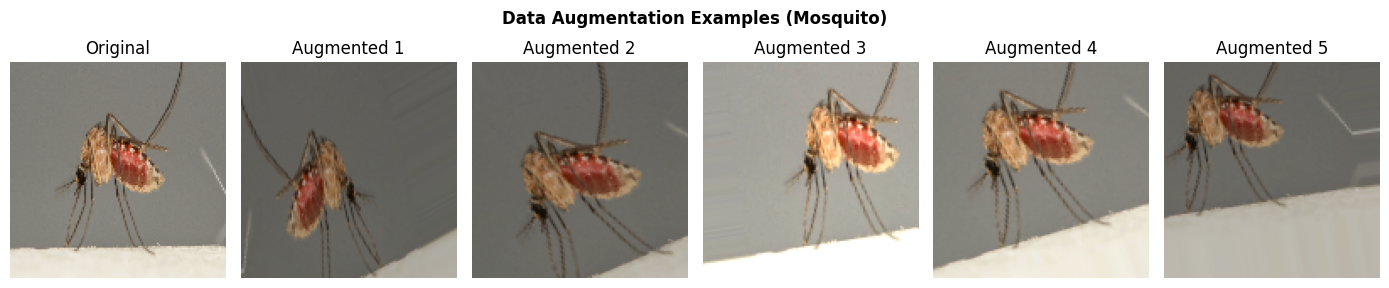

Data augmentation artificially expands the dataset by creating varied versions of each image.
This is CRITICAL for small datasets to prevent overfitting.


In [10]:
# Augmented sample images
aug_gen = ImageDataGenerator(
    rotation_range=30, width_shift_range=0.2, height_shift_range=0.2,
    shear_range=0.2, zoom_range=0.25, horizontal_flip=True,
    brightness_range=[0.7, 1.3], fill_mode='nearest'
)

sample_path = list((SOURCE_DIR / 'mosquito').glob("*.jpg"))[0]
sample_img = kimg.load_img(str(sample_path), target_size=(IMG_SIZE, IMG_SIZE))
sample_arr = np.expand_dims(kimg.img_to_array(sample_img), axis=0)

fig, axes = plt.subplots(1, 6, figsize=(14, 3))
axes[0].imshow(sample_img); axes[0].set_title("Original"); axes[0].axis('off')
aug_iter = aug_gen.flow(sample_arr, batch_size=1)
for i in range(1, 6):
    aug_img = next(aug_iter)[0].astype(np.uint8)
    axes[i].imshow(aug_img)
    axes[i].set_title(f"Augmented {i}")
    axes[i].axis('off')
plt.suptitle("Data Augmentation Examples (Mosquito)", fontweight='bold')
plt.tight_layout()
plt.savefig("augmented_samples.png", dpi=150)
plt.show()
print("Data augmentation artificially expands the dataset by creating varied versions of each image.")
print("This is CRITICAL for small datasets to prevent overfitting.")

## 3. Part A.1 - Baseline CNN (3 Conv + 3 FCN)

In [11]:
# Data generators
train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=30, width_shift_range=0.2, height_shift_range=0.2,
    shear_range=0.2, zoom_range=0.25, horizontal_flip=True,
    brightness_range=[0.7, 1.3], fill_mode='nearest'
)
val_test_datagen = ImageDataGenerator(rescale=1./255)

train_gen = train_datagen.flow_from_directory(
    TRAIN_DIR, target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE, class_mode='categorical', shuffle=True, seed=42)
val_gen = val_test_datagen.flow_from_directory(
    VAL_DIR, target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE, class_mode='categorical', shuffle=False)
test_gen = val_test_datagen.flow_from_directory(
    TEST_DIR, target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=1, class_mode='categorical', shuffle=False)

print("Classes:", train_gen.class_indices)

Found 145 images belonging to 5 classes.
Found 29 images belonging to 5 classes.
Found 36 images belonging to 5 classes.
Classes: {'aphids': 0, 'armyworm': 1, 'mosquito': 2, 'sawfly': 3, 'stem_borer': 4}


In [12]:
# Build Baseline CNN
def build_baseline_cnn(input_shape=(128, 128, 3), num_classes=5):
    model = models.Sequential([
        # Block 1: Conv -> Pool
        layers.Conv2D(32, (3,3), activation='relu', padding='same',
                      input_shape=input_shape, name='conv1'),
        layers.MaxPooling2D((2,2), name='pool1'),
        # Block 2: Conv -> Pool
        layers.Conv2D(64, (3,3), activation='relu', padding='same', name='conv2'),
        layers.MaxPooling2D((2,2), name='pool2'),
        # Block 3: Conv -> Pool
        layers.Conv2D(128, (3,3), activation='relu', padding='same', name='conv3'),
        layers.MaxPooling2D((2,2), name='pool3'),
        # Flatten + 3 Fully Connected Layers
        layers.Flatten(name='flatten'),
        layers.Dense(256, activation='relu', name='fc1'),
        layers.Dense(128, activation='relu', name='fc2'),
        layers.Dense(64,  activation='relu', name='fc3'),
        layers.Dense(num_classes, activation='softmax', name='output')
    ], name='BaselineCNN')
    return model

baseline_model = build_baseline_cnn()
baseline_model.summary()
print(f"Total parameters: {baseline_model.count_params():,}")

Model: "BaselineCNN"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv1 (Conv2D)                  │ (None, 128, 128, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ pool1 (MaxPooling2D)            │ (None, 64, 64, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2 (Conv2D)                  │ (None, 64, 64, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ pool2 (MaxPooling2D)            │ (None, 32, 32, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv3 (Conv2D)                  │ (None, 32, 32, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ pool3 (MaxPooling2D)            │ (None, 16, 16, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 32768)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ fc1 (Dense)                     │ (None, 256)            │     8,388,864 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ fc2 (Dense)                     │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ fc3 (Dense)                     │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output (Dense)                  │ (None, 5)              │           325 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 8,523,589 (32.51 MB)

 Trainable params: 8,523,589 (32.51 MB)

 Non-trainable params: 0 (0.00 B)

Total parameters: 8,523,589


In [13]:
# Compile and train baseline
baseline_model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=1e-3),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)
EPOCHS = 50
callbacks_base = [
    EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True, verbose=1),
    ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=5, verbose=1)
]
t0 = time.time()
history_baseline = baseline_model.fit(
    train_gen, epochs=EPOCHS, validation_data=val_gen,
    callbacks=callbacks_base, verbose=1
)
baseline_train_time = time.time() - t0
print(f"Baseline training time: {baseline_train_time:.1f}s")

Epoch 1/50
19/19 ━━━━━━━━━━━━━━━━━━━━ 6s 226ms/step - accuracy: 0.2069 - loss: 1.6579 - val_accuracy: 0.2759 - val_loss: 1.6045 - learning_rate: 0.0010
Epoch 2/50
19/19 ━━━━━━━━━━━━━━━━━━━━ 5s 260ms/step - accuracy: 0.2483 - loss: 1.6266 - val_accuracy: 0.2414 - val_loss: 1.6019 - learning_rate: 0.0010
Epoch 3/50
19/19 ━━━━━━━━━━━━━━━━━━━━ 4s 213ms/step - accuracy: 0.1793 - loss: 1.6177 - val_accuracy: 0.2069 - val_loss: 1.6106 - learning_rate: 0.0010
Epoch 4/50
19/19 ━━━━━━━━━━━━━━━━━━━━ 4s 218ms/step - accuracy: 0.2345 - loss: 1.6122 - val_accuracy: 0.2414 - val_loss: 1.5925 - learning_rate: 0.0010
Epoch 5/50
19/19 ━━━━━━━━━━━━━━━━━━━━ 5s 244ms/step - accuracy: 0.2414 - loss: 1.6199 - val_accuracy: 0.2414 - val_loss: 1.5867 - learning_rate: 0.0010
Epoch 6/50
19/19 ━━━━━━━━━━━━━━━━━━━━ 4s 213ms/step - accuracy: 0.2414 - loss: 1.6099 - val_accuracy: 0.2414 - val_loss: 1.5969 - learning_rate: 0.0010
Epoch 7/50
19/19 ━━━━━━━━━━━━━━━━━━━━ 5s 238ms/step - accuracy: 0.2483 - loss: 1.6040 - 

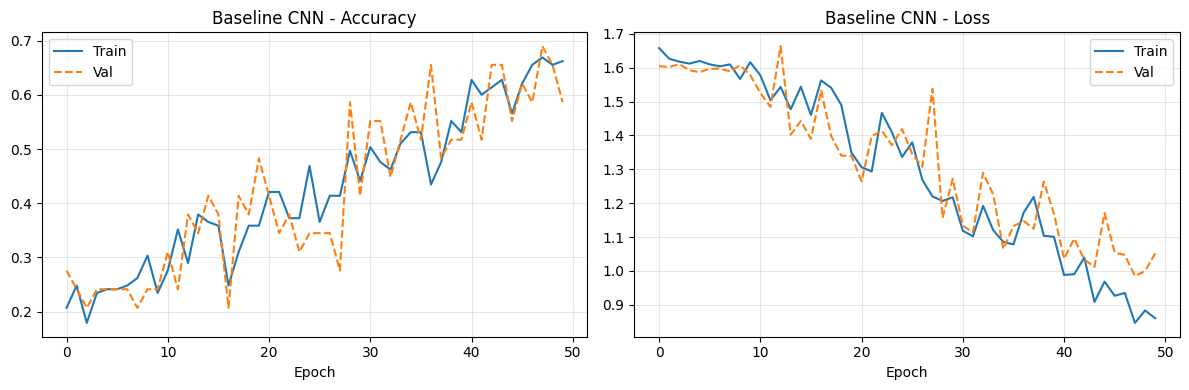

In [14]:
# Plot training curves helper function
def plot_history(history, title="Training History"):
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))
    ax1.plot(history.history['accuracy'], label='Train', color='#1f77b4')
    ax1.plot(history.history['val_accuracy'], label='Val', color='#ff7f0e', linestyle='--')
    ax1.set_title(f"{title} - Accuracy")
    ax1.set_xlabel("Epoch"); ax1.legend(); ax1.grid(alpha=0.3)
    ax2.plot(history.history['loss'], label='Train', color='#1f77b4')
    ax2.plot(history.history['val_loss'], label='Val', color='#ff7f0e', linestyle='--')
    ax2.set_title(f"{title} - Loss")
    ax2.set_xlabel("Epoch"); ax2.legend(); ax2.grid(alpha=0.3)
    plt.tight_layout()
    plt.savefig(f"{title.replace(' ','_')}.png", dpi=150)
    plt.show()

plot_history(history_baseline, "Baseline CNN")


Baseline CNN  |  Accuracy: 61.11%  |  Loss: 1.5235


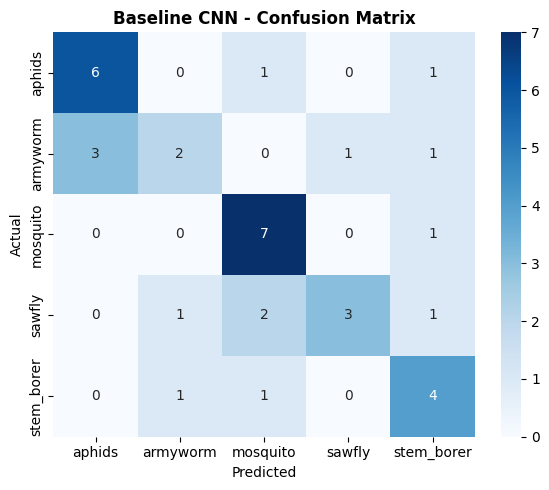

              precision    recall  f1-score   support

      aphids       0.67      0.75      0.71         8
    armyworm       0.50      0.29      0.36         7
    mosquito       0.64      0.88      0.74         8
      sawfly       0.75      0.43      0.55         7
  stem_borer       0.50      0.67      0.57         6

    accuracy                           0.61        36
   macro avg       0.61      0.60      0.58        36
weighted avg       0.62      0.61      0.59        36



In [15]:
# Evaluate model - helper function
def evaluate_model(model, gen, model_name):
    gen.reset()
    loss, acc = model.evaluate(gen, verbose=0)
    print(f"\n{'='*40}")
    print(f"{model_name}  |  Accuracy: {acc*100:.2f}%  |  Loss: {loss:.4f}")
    print('='*40)
    gen.reset()
    y_pred = np.argmax(model.predict(gen, verbose=0), axis=1)
    y_true = gen.classes
    labels = list(gen.class_indices.keys())
    # Confusion matrix
    cm = confusion_matrix(y_true, y_pred)
    fig, ax = plt.subplots(figsize=(6, 5))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=labels, yticklabels=labels, ax=ax)
    ax.set_title(f"{model_name} - Confusion Matrix", fontweight='bold')
    ax.set_xlabel("Predicted"); ax.set_ylabel("Actual")
    plt.tight_layout()
    plt.savefig(f"cm_{model_name.replace(' ','_')}.png", dpi=150)
    plt.show()
    print(classification_report(y_true, y_pred, target_names=labels))
    return acc, loss

baseline_acc, baseline_loss = evaluate_model(baseline_model, test_gen, "Baseline CNN")

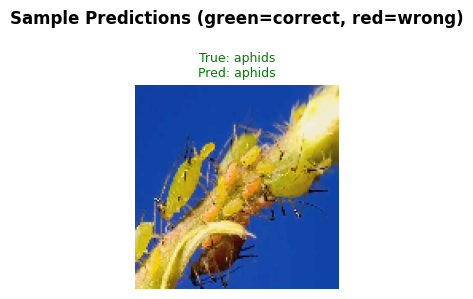

In [16]:
# Inference on sample images
def predict_samples(model, gen, n=5):
    gen.reset()
    batch_x, batch_y = next(gen)
    labels = list(gen.class_indices.keys())
    num_samples_to_show = min(n, len(batch_x))
    fig, axes = plt.subplots(1, num_samples_to_show, figsize=(15, 3))

    # Handle the case where only one subplot is created (axes is not an array)
    if num_samples_to_show == 1:
        axes = [axes] # Convert the single Axes object into a list

    for i in range(num_samples_to_show):
        pred = labels[np.argmax(model.predict(np.expand_dims(batch_x[i], 0), verbose=0))]
        true = labels[np.argmax(batch_y[i])]
        axes[i].imshow(batch_x[i])
        color = 'green' if pred == true else 'red'
        axes[i].set_title(f"True: {true}\nPred: {pred}", color=color, fontsize=9)
        axes[i].axis('off')
    plt.suptitle("Sample Predictions (green=correct, red=wrong)", fontweight='bold')
    plt.tight_layout(); plt.show()

predict_samples(baseline_model, test_gen)

## 4. Part A.2 - Deeper CNN with Batch Normalization and Dropout

In [17]:
# Build Deeper CNN - double the layers with regularization
def build_deeper_cnn(input_shape=(128, 128, 3), num_classes=5):
    model = models.Sequential([
        # Block 1: 2x Conv + BatchNorm + Pool + Dropout
        layers.Conv2D(32, (3,3), activation='relu', padding='same', input_shape=input_shape),
        layers.BatchNormalization(),
        layers.Conv2D(32, (3,3), activation='relu', padding='same'),
        layers.BatchNormalization(),
        layers.MaxPooling2D((2,2)),
        layers.Dropout(0.25),
        # Block 2
        layers.Conv2D(64, (3,3), activation='relu', padding='same'),
        layers.BatchNormalization(),
        layers.Conv2D(64, (3,3), activation='relu', padding='same'),
        layers.BatchNormalization(),
        layers.MaxPooling2D((2,2)),
        layers.Dropout(0.25),
        # Block 3
        layers.Conv2D(128, (3,3), activation='relu', padding='same'),
        layers.BatchNormalization(),
        layers.Conv2D(128, (3,3), activation='relu', padding='same'),
        layers.BatchNormalization(),
        layers.MaxPooling2D((2,2)),
        layers.Dropout(0.25),
        # Block 4 (deeper than baseline)
        layers.Conv2D(256, (3,3), activation='relu', padding='same'),
        layers.BatchNormalization(),
        layers.Conv2D(256, (3,3), activation='relu', padding='same'),
        layers.BatchNormalization(),
        layers.MaxPooling2D((2,2)),
        layers.Dropout(0.4),
        # FCN
        layers.Flatten(),
        layers.Dense(512, activation='relu'),
        layers.BatchNormalization(),
        layers.Dropout(0.5),
        layers.Dense(256, activation='relu'),
        layers.Dropout(0.3),
        layers.Dense(128, activation='relu'),
        layers.Dense(num_classes, activation='softmax')
    ], name='DeeperCNN')
    return model

deeper_model = build_deeper_cnn()
deeper_model.summary()
print(f"Baseline params: {baseline_model.count_params():,}")
print(f"Deeper params:   {deeper_model.count_params():,}")

Model: "DeeperCNN"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 128, 128, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 128, 128, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 128, 128, 32)   │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 128, 128, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 64, 64, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64, 64, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 64, 64, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 64, 64, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 64, 64, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 64, 64, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 32, 32, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 32, 32, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 32, 32, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 32, 32, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 32, 32, 128)    │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_5           │ (None, 32, 32, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 16, 16, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 16, 16, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_6 (Conv2D)               │ (None, 16, 16, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_6           │ (None, 16, 16, 256)    │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_7 (Conv2D)               │ (None, 16, 16, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼─────────────

 Total params: 9,732,133 (37.13 MB)

 Trainable params: 9,729,189 (37.11 MB)

 Non-trainable params: 2,944 (11.50 KB)

Baseline params: 8,523,589
Deeper params:   9,732,133


Epoch 1/50
19/19 ━━━━━━━━━━━━━━━━━━━━ 21s 842ms/step - accuracy: 0.2552 - loss: 2.0957 - val_accuracy: 0.2759 - val_loss: 1.5768 - learning_rate: 0.0010
Epoch 2/50
19/19 ━━━━━━━━━━━━━━━━━━━━ 15s 815ms/step - accuracy: 0.2483 - loss: 1.9465 - val_accuracy: 0.2069 - val_loss: 2.0942 - learning_rate: 0.0010
Epoch 3/50
19/19 ━━━━━━━━━━━━━━━━━━━━ 16s 821ms/step - accuracy: 0.2759 - loss: 1.8432 - val_accuracy: 0.2414 - val_loss: 4.0526 - learning_rate: 0.0010
Epoch 4/50
19/19 ━━━━━━━━━━━━━━━━━━━━ 16s 866ms/step - accuracy: 0.2345 - loss: 1.9928 - val_accuracy: 0.2069 - val_loss: 3.8616 - learning_rate: 0.0010
Epoch 5/50
19/19 ━━━━━━━━━━━━━━━━━━━━ 16s 852ms/step - accuracy: 0.2690 - loss: 1.8476 - val_accuracy: 0.2414 - val_loss: 2.7226 - learning_rate: 0.0010
Epoch 6/50
19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 774ms/step - accuracy: 0.2437 - loss: 1.7811
Epoch 6: ReduceLROnPlateau reducing learning rate to 0.0005000000237487257.
19/19 ━━━━━━━━━━━━━━━━━━━━ 15s 812ms/step - accuracy: 0.2552 - loss: 1.85

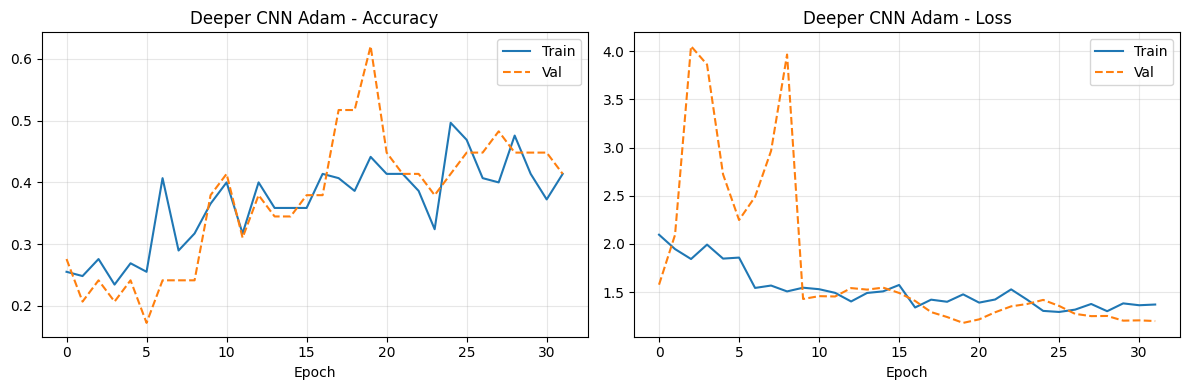


Deeper CNN  |  Accuracy: 47.22%  |  Loss: 1.3778


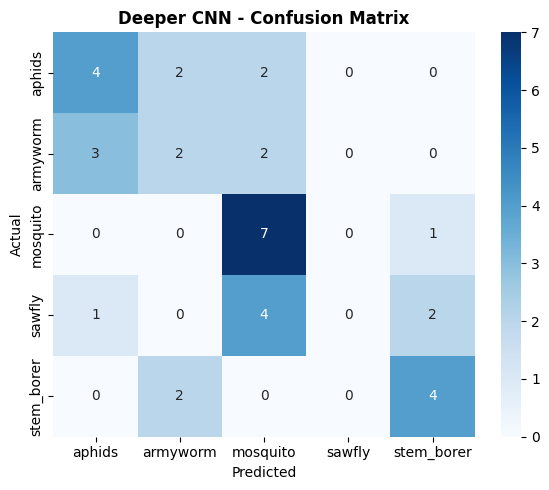

              precision    recall  f1-score   support

      aphids       0.50      0.50      0.50         8
    armyworm       0.33      0.29      0.31         7
    mosquito       0.47      0.88      0.61         8
      sawfly       0.00      0.00      0.00         7
  stem_borer       0.57      0.67      0.62         6

    accuracy                           0.47        36
   macro avg       0.37      0.47      0.41        36
weighted avg       0.37      0.47      0.41        36



In [18]:
# Train deeper CNN with Adam
deeper_model.compile(
    optimizer=keras.optimizers.Adam(1e-3),
    loss='categorical_crossentropy', metrics=['accuracy']
)
callbacks_deep = [
    EarlyStopping(monitor='val_loss', patience=12, restore_best_weights=True, verbose=1),
    ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=5, min_lr=1e-6, verbose=1)
]
t0 = time.time()
history_deeper = deeper_model.fit(
    train_gen, epochs=EPOCHS, validation_data=val_gen,
    callbacks=callbacks_deep, verbose=1
)
deeper_train_time = time.time() - t0
print(f"Deeper CNN training time: {deeper_train_time:.1f}s  |  Baseline: {baseline_train_time:.1f}s")
plot_history(history_deeper, "Deeper CNN Adam")
deeper_acc, deeper_loss = evaluate_model(deeper_model, test_gen, "Deeper CNN")

## 5. Part A.3 - Optimizer Comparison: Adam vs SGD

Epoch 1/50
19/19 ━━━━━━━━━━━━━━━━━━━━ 19s 848ms/step - accuracy: 0.2069 - loss: 2.1721 - val_accuracy: 0.1724 - val_loss: 8433.0283
Epoch 2/50
19/19 ━━━━━━━━━━━━━━━━━━━━ 19s 795ms/step - accuracy: 0.1586 - loss: 2.1186 - val_accuracy: 0.2069 - val_loss: 136.0202
Epoch 3/50
19/19 ━━━━━━━━━━━━━━━━━━━━ 16s 873ms/step - accuracy: 0.2000 - loss: 1.8168 - val_accuracy: 0.1724 - val_loss: 23.2263
Epoch 4/50
19/19 ━━━━━━━━━━━━━━━━━━━━ 15s 797ms/step - accuracy: 0.2552 - loss: 1.6720 - val_accuracy: 0.2069 - val_loss: 6.8826
Epoch 5/50
19/19 ━━━━━━━━━━━━━━━━━━━━ 15s 800ms/step - accuracy: 0.2759 - loss: 1.6351 - val_accuracy: 0.2759 - val_loss: 1.8539
Epoch 6/50
19/19 ━━━━━━━━━━━━━━━━━━━━ 21s 806ms/step - accuracy: 0.2207 - loss: 1.6731 - val_accuracy: 0.2414 - val_loss: 1.7507
Epoch 7/50
19/19 ━━━━━━━━━━━━━━━━━━━━ 16s 819ms/step - accuracy: 0.2828 - loss: 1.6121 - val_accuracy: 0.2414 - val_loss: 2.1570
Epoch 8/50
19/19 ━━━━━━━━━━━━━━━━━━━━ 15s 803ms/step - accuracy: 0.3310 - loss: 1.5885 - va

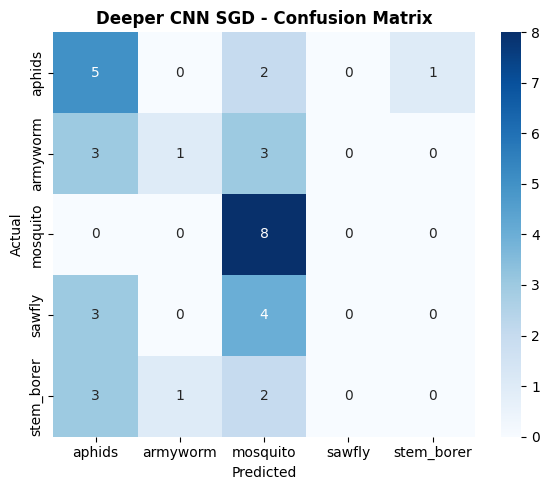

              precision    recall  f1-score   support

      aphids       0.36      0.62      0.45         8
    armyworm       0.50      0.14      0.22         7
    mosquito       0.42      1.00      0.59         8
      sawfly       0.00      0.00      0.00         7
  stem_borer       0.00      0.00      0.00         6

    accuracy                           0.39        36
   macro avg       0.26      0.35      0.25        36
weighted avg       0.27      0.39      0.28        36



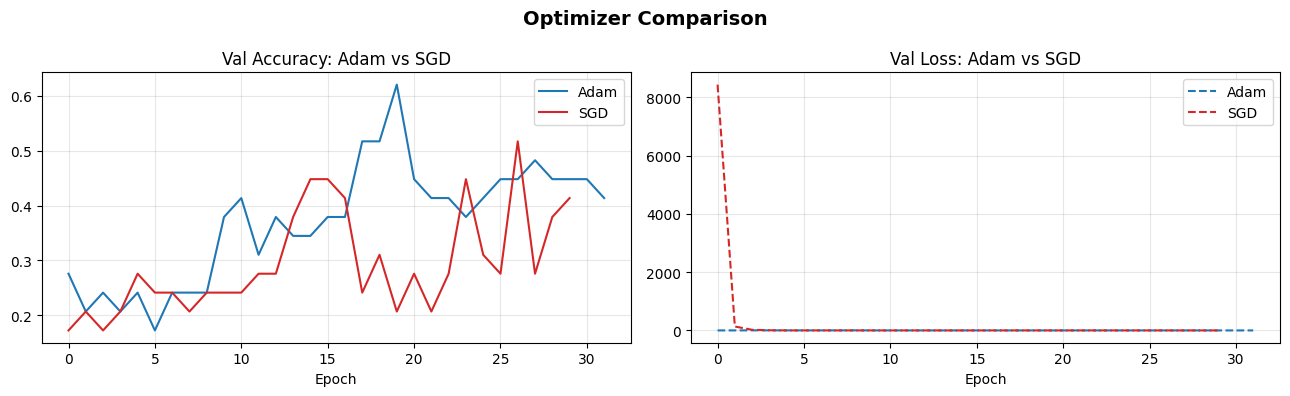

Adam val acc: 0.6207
SGD  val acc: 0.5172
Observation: Adam typically converges faster and achieves higher accuracy.
SGD with momentum is more stable but needs more epochs.


In [19]:
# Train deeper CNN with SGD
deeper_sgd = build_deeper_cnn()
deeper_sgd.compile(
    optimizer=keras.optimizers.SGD(learning_rate=0.01, momentum=0.9, nesterov=True),
    loss='categorical_crossentropy', metrics=['accuracy']
)
t0 = time.time()
history_sgd = deeper_sgd.fit(
    train_gen, epochs=EPOCHS, validation_data=val_gen,
    callbacks=[EarlyStopping(patience=15, restore_best_weights=True, verbose=1)], verbose=1
)
sgd_time = time.time() - t0
sgd_acc, sgd_loss = evaluate_model(deeper_sgd, test_gen, "Deeper CNN SGD")

# Comparison plot
fig, axes = plt.subplots(1, 2, figsize=(13, 4))
for h, label, color in [(history_deeper, 'Adam', '#1f77b4'), (history_sgd, 'SGD', '#d62728')]:
    axes[0].plot(h.history['val_accuracy'], label=label, color=color)
    axes[1].plot(h.history['val_loss'], label=label, color=color, linestyle='--')
for ax, t in zip(axes, ["Val Accuracy", "Val Loss"]):
    ax.set_title(f"{t}: Adam vs SGD"); ax.legend(); ax.grid(alpha=0.3); ax.set_xlabel("Epoch")
plt.suptitle("Optimizer Comparison", fontsize=14, fontweight='bold')
plt.tight_layout(); plt.savefig("optimizer_comparison.png", dpi=150); plt.show()
print(f"Adam val acc: {max(history_deeper.history['val_accuracy']):.4f}")
print(f"SGD  val acc: {max(history_sgd.history['val_accuracy']):.4f}")
print("Observation: Adam typically converges faster and achieves higher accuracy.")
print("SGD with momentum is more stable but needs more epochs.")

## 6. Part A.4 - Ablation Study (Remove Dropout)

Epoch 1/50
19/19 ━━━━━━━━━━━━━━━━━━━━ 13s 533ms/step - accuracy: 0.2897 - loss: 8.2733 - val_accuracy: 0.1379 - val_loss: 2.2672 - learning_rate: 0.0010
Epoch 2/50
19/19 ━━━━━━━━━━━━━━━━━━━━ 10s 526ms/step - accuracy: 0.3448 - loss: 5.0790 - val_accuracy: 0.1724 - val_loss: 2.1959 - learning_rate: 0.0010
Epoch 3/50
19/19 ━━━━━━━━━━━━━━━━━━━━ 10s 524ms/step - accuracy: 0.3724 - loss: 3.9574 - val_accuracy: 0.2414 - val_loss: 6.7150 - learning_rate: 0.0010
Epoch 4/50
19/19 ━━━━━━━━━━━━━━━━━━━━ 10s 525ms/step - accuracy: 0.3793 - loss: 3.8064 - val_accuracy: 0.1724 - val_loss: 2.8275 - learning_rate: 0.0010
Epoch 5/50
19/19 ━━━━━━━━━━━━━━━━━━━━ 10s 507ms/step - accuracy: 0.3241 - loss: 2.9238 - val_accuracy: 0.2069 - val_loss: 6.3424 - learning_rate: 0.0010
Epoch 6/50
19/19 ━━━━━━━━━━━━━━━━━━━━ 9s 480ms/step - accuracy: 0.4276 - loss: 2.1922 - val_accuracy: 0.2069 - val_loss: 6.0983 - learning_rate: 0.0010
Epoch 7/50
19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 546ms/step - accuracy: 0.2672 - loss: 3.91

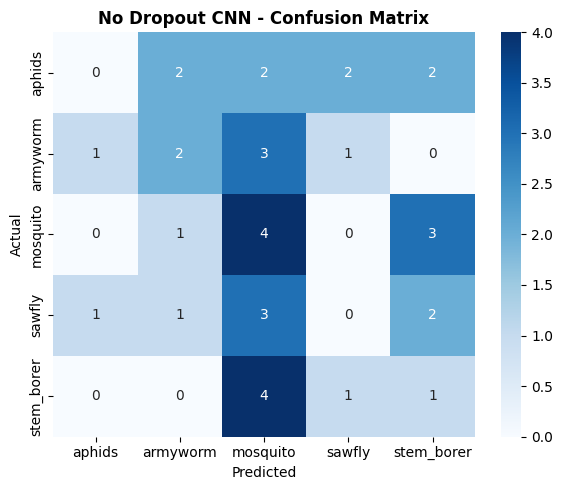

              precision    recall  f1-score   support

      aphids       0.00      0.00      0.00         8
    armyworm       0.33      0.29      0.31         7
    mosquito       0.25      0.50      0.33         8
      sawfly       0.00      0.00      0.00         7
  stem_borer       0.12      0.17      0.14         6

    accuracy                           0.19        36
   macro avg       0.14      0.19      0.16        36
weighted avg       0.14      0.19      0.16        36

With Dropout val acc: 0.6207
No Dropout  val acc: 0.3103
Observation: Removing dropout typically causes overfitting (train acc >> val acc).


In [27]:
# Same deeper architecture but WITHOUT dropout
def build_no_dropout(input_shape=(128, 128, 3), num_classes=5):
    model = models.Sequential([
        layers.Conv2D(32, (3,3), activation='relu', padding='same', input_shape=input_shape),
        layers.BatchNormalization(),
        layers.Conv2D(32, (3,3), activation='relu', padding='same'),
        layers.MaxPooling2D((2,2)),
        layers.Conv2D(64, (3,3), activation='relu', padding='same'),
        layers.BatchNormalization(),
        layers.Conv2D(64, (3,3), activation='relu', padding='same'),
        layers.MaxPooling2D((2,2)),
        layers.Conv2D(128, (3,3), activation='relu', padding='same'),
        layers.BatchNormalization(),
        layers.MaxPooling2D((2,2)),
        layers.Flatten(),
        layers.Dense(256, activation='relu'),
        layers.Dense(128, activation='relu'),
        layers.Dense(num_classes, activation='softmax')
    ], name='NoDroupoutCNN')
    return model

ablation = build_no_dropout()
ablation.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

# Added ReduceLROnPlateau for better convergence efficiency
callbacks_abl = [
    EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True, verbose=1),
    ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=5, min_lr=1e-6, verbose=1)
]

history_abl = ablation.fit(
    train_gen, epochs=50, validation_data=val_gen,
    callbacks=callbacks_abl, verbose=1
)

abl_acc, abl_loss = evaluate_model(ablation, test_gen, "No Dropout CNN")

print(f"With Dropout val acc: {max(history_deeper.history['val_accuracy']):.4f}")
print(f"No Dropout  val acc: {max(history_abl.history['val_accuracy']):.4f}")
print("Observation: Removing dropout typically causes overfitting (train acc >> val acc).")

## 7. Model Summary Table

        Model  Test Acc (%) Train Time (s)    Params
 Baseline CNN         61.11          222.7 8,523,589
Deeper (Adam)         47.22          526.6 9,732,133
 Deeper (SGD)         38.89          496.3 9,732,133
   No Dropout         19.44            N/A 8,562,725


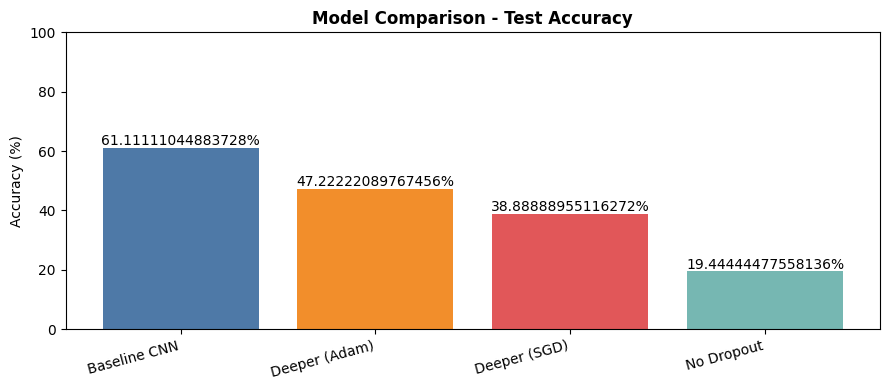

In [21]:
results = pd.DataFrame({
    "Model":         ["Baseline CNN", "Deeper (Adam)", "Deeper (SGD)", "No Dropout"],
    "Test Acc (%)":  [round(baseline_acc*100,2), round(deeper_acc*100,2),
                      round(sgd_acc*100,2), round(abl_acc*100,2)],
    "Train Time (s)":[round(baseline_train_time,1), round(deeper_train_time,1),
                      round(sgd_time,1), "N/A"],
    "Params":        [f"{baseline_model.count_params():,}", f"{deeper_model.count_params():,}",
                      f"{deeper_sgd.count_params():,}", f"{ablation.count_params():,}"]
})
print(results.to_string(index=False))

fig, ax = plt.subplots(figsize=(9, 4))
colors = ['#4e79a7','#f28e2b','#e15759','#76b7b2']
accs = [baseline_acc*100, deeper_acc*100, sgd_acc*100, abl_acc*100]
bars = ax.bar(results["Model"], accs, color=colors)
ax.set_title("Model Comparison - Test Accuracy", fontweight='bold')
ax.set_ylabel("Accuracy (%)"); ax.set_ylim(0, 100)
for bar, v in zip(bars, accs):
    ax.text(bar.get_x()+bar.get_width()/2, v+1, f"{v}%", ha='center', fontsize=10)
plt.xticks(rotation=15, ha='right')
plt.tight_layout(); plt.savefig("model_comparison.png", dpi=150); plt.show()

## 8. Part B - Transfer Learning with MobileNetV2

In [22]:
# MobileNetV2 requires 224x224 input - new generators
IMG_TL = 224
tl_train = ImageDataGenerator(rescale=1./255, rotation_range=30,
    width_shift_range=0.2, height_shift_range=0.2,
    horizontal_flip=True, zoom_range=0.2
).flow_from_directory(TRAIN_DIR, target_size=(IMG_TL,IMG_TL),
    batch_size=BATCH_SIZE, class_mode='categorical')
tl_val = ImageDataGenerator(rescale=1./255).flow_from_directory(
    VAL_DIR, target_size=(IMG_TL,IMG_TL), batch_size=BATCH_SIZE,
    class_mode='categorical', shuffle=False)
tl_test = ImageDataGenerator(rescale=1./255).flow_from_directory(
    TEST_DIR, target_size=(IMG_TL,IMG_TL), batch_size=1,
    class_mode='categorical', shuffle=False)

# Load pre-trained MobileNetV2 (ImageNet weights, no top)
base_model = MobileNetV2(input_shape=(IMG_TL,IMG_TL,3),
                         include_top=False, weights='imagenet')
base_model.trainable = False   # Freeze all layers first
print(f"MobileNetV2 loaded: {base_model.count_params():,} frozen parameters")

Found 145 images belonging to 5 classes.
Found 29 images belonging to 5 classes.
Found 36 images belonging to 5 classes.
9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
MobileNetV2 loaded: 2,257,984 frozen parameters


In [23]:
# Add custom classification head for 5 insect classes
inputs = keras.Input(shape=(IMG_TL, IMG_TL, 3))
x = base_model(inputs, training=False)
x = layers.GlobalAveragePooling2D()(x)
x = layers.Dense(256, activation='relu')(x)
x = layers.BatchNormalization()(x)
x = layers.Dropout(0.4)(x)
x = layers.Dense(128, activation='relu')(x)
outputs = layers.Dense(NUM_CLASSES, activation='softmax')(x)
tl_model = keras.Model(inputs, outputs, name='MobileNetV2_InsectClassifier')
tl_model.summary()

Model: "MobileNetV2_InsectClassifier"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_5 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ mobilenetv2_1.00_224            │ (None, 7, 7, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_11 (Dense)                │ (None, 256)            │       327,936 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_21          │ (None, 256)            │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_12 (Dropout)            │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_12 (Dense)                │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_13 (Dense)                │ (None, 5)              │           645 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,620,485 (10.00 MB)

 Trainable params: 361,989 (1.38 MB)

 Non-trainable params: 2,258,496 (8.62 MB)

In [24]:
# Phase 1: Feature Extraction (frozen base)
tl_model.compile(optimizer=keras.optimizers.Adam(1e-3),
                 loss='categorical_crossentropy', metrics=['accuracy'])
print("Phase 1: Feature Extraction (base frozen)...")
history_tl1 = tl_model.fit(
    tl_train, epochs=20, validation_data=tl_val,
    callbacks=[EarlyStopping(patience=6, restore_best_weights=True, verbose=1)],
    verbose=1
)
print("Phase 1 complete.")

Phase 1: Feature Extraction (base frozen)...
Epoch 1/20
19/19 ━━━━━━━━━━━━━━━━━━━━ 9s 266ms/step - accuracy: 0.4000 - loss: 1.5081 - val_accuracy: 0.5862 - val_loss: 1.3835
Epoch 2/20
19/19 ━━━━━━━━━━━━━━━━━━━━ 5s 258ms/step - accuracy: 0.7310 - loss: 0.7285 - val_accuracy: 0.6552 - val_loss: 1.1822
Epoch 3/20
19/19 ━━━━━━━━━━━━━━━━━━━━ 4s 209ms/step - accuracy: 0.8345 - loss: 0.5210 - val_accuracy: 0.6552 - val_loss: 1.1756
Epoch 4/20
19/19 ━━━━━━━━━━━━━━━━━━━━ 4s 217ms/step - accuracy: 0.8621 - loss: 0.4975 - val_accuracy: 0.7241 - val_loss: 1.2223
Epoch 5/20
19/19 ━━━━━━━━━━━━━━━━━━━━ 5s 248ms/step - accuracy: 0.8345 - loss: 0.4370 - val_accuracy: 0.8276 - val_loss: 0.9104
Epoch 6/20
19/19 ━━━━━━━━━━━━━━━━━━━━ 4s 223ms/step - accuracy: 0.8966 - loss: 0.3054 - val_accuracy: 0.8276 - val_loss: 0.6838
Epoch 7/20
19/19 ━━━━━━━━━━━━━━━━━━━━ 5s 266ms/step - accuracy: 0.9310 - loss: 0.2143 - val_accuracy: 0.8276 - val_loss: 0.6295
Epoch 8/20
19/19 ━━━━━━━━━━━━━━━━━━━━ 4s 212ms/step - accur

Phase 2: Deep Fine-tuning top 100 layers...
Epoch 1/50
19/19 ━━━━━━━━━━━━━━━━━━━━ 15s 362ms/step - accuracy: 0.7862 - loss: 0.6081 - val_accuracy: 0.8276 - val_loss: 0.6118
Epoch 2/50
19/19 ━━━━━━━━━━━━━━━━━━━━ 7s 349ms/step - accuracy: 0.7793 - loss: 0.6347 - val_accuracy: 0.8276 - val_loss: 0.6631
Epoch 3/50
19/19 ━━━━━━━━━━━━━━━━━━━━ 6s 304ms/step - accuracy: 0.8138 - loss: 0.4812 - val_accuracy: 0.8276 - val_loss: 0.7017
Epoch 4/50
19/19 ━━━━━━━━━━━━━━━━━━━━ 7s 347ms/step - accuracy: 0.8345 - loss: 0.4944 - val_accuracy: 0.8276 - val_loss: 0.7316
Epoch 5/50
19/19 ━━━━━━━━━━━━━━━━━━━━ 6s 302ms/step - accuracy: 0.8552 - loss: 0.4240 - val_accuracy: 0.8276 - val_loss: 0.7739
Epoch 6/50
19/19 ━━━━━━━━━━━━━━━━━━━━ 7s 348ms/step - accuracy: 0.8483 - loss: 0.4061 - val_accuracy: 0.7586 - val_loss: 0.8056
Epoch 7/50
19/19 ━━━━━━━━━━━━━━━━━━━━ 6s 318ms/step - accuracy: 0.8483 - loss: 0.4080 - val_accuracy: 0.7586 - val_loss: 0.8222
Epoch 8/50
19/19 ━━━━━━━━━━━━━━━━━━━━ 7s 354ms/step - accur

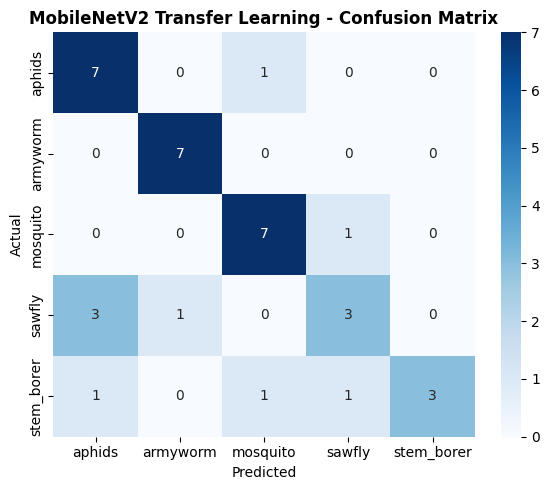

              precision    recall  f1-score   support

      aphids       0.64      0.88      0.74         8
    armyworm       0.88      1.00      0.93         7
    mosquito       0.78      0.88      0.82         8
      sawfly       0.60      0.43      0.50         7
  stem_borer       1.00      0.50      0.67         6

    accuracy                           0.75        36
   macro avg       0.78      0.74      0.73        36
weighted avg       0.77      0.75      0.74        36


=== FINAL COMPARISON ===
Baseline CNN:         61.11%
Deeper CNN (Adam):    47.22%
MobileNetV2 (TL):     75.00%


In [26]:
# Phase 2: Fine-tune top 100 layers of base model (more aggressive fine-tuning)
base_model.trainable = True
# Unfreeze top 100 layers instead of 50
for layer in base_model.layers[:-100]:
    layer.trainable = False

# Using a very low learning rate with a decay schedule
initial_lr = 1e-5
lr_schedule = keras.optimizers.schedules.ExponentialDecay(
    initial_lr, decay_steps=100, decay_rate=0.96, staircase=True)

tl_model.compile(optimizer=keras.optimizers.Adam(learning_rate=lr_schedule),
                 loss='categorical_crossentropy', metrics=['accuracy'])

print("Phase 2: Deep Fine-tuning top 100 layers...")
history_tl2 = tl_model.fit(
    tl_train, epochs=50, validation_data=tl_val,
    callbacks=[EarlyStopping(patience=15, restore_best_weights=True, verbose=1)],
    verbose=1
)

tl_acc, tl_loss = evaluate_model(tl_model, tl_test, "MobileNetV2 Transfer Learning")

print("\n=== FINAL COMPARISON ===")
print(f"Baseline CNN:         {baseline_acc*100:.2f}%")
print(f"Deeper CNN (Adam):    {deeper_acc*100:.2f}%")
print(f"MobileNetV2 (TL):     {tl_acc*100:.2f}%")